# 09 — Recurrent agent (GRU / LSTM) + ARIMA baseline

**Why this notebook exists.** The thesis advisor asked two methodological questions:

1. The fund uses *exotic* sequence models (Mamba, TCN, PatchTST) but never the **standard recurrent
   net** (LSTM / GRU). Does a textbook recurrent model do any better?
2. There is no **classical statistical baseline** (ARIMA / random-walk).

**What it does.**
- Trains a recurrent direction classifier — `nn.GRU` *and* `nn.LSTM`, one shared harness — as a
  *real candidate agent* in the `notebooks_v2 -> mas07` pipeline. It is a faithful clone of
  `02_mamba_v1` (same Triple-Barrier labels, expanding-window WFO, `SEQ_LEN=24`, fold-local
  percentile signal, identical ATR-bracket trading grid and fee model). Only the encoder changes.
- **Decision gate (predeclared):** if the recurrent agent's standalone OOS return is **≥ 10% / yr**,
  it is promoted into the multi-agent fund; otherwise it is reported as an honest negative alongside
  DRL and GP/GA. Declaring the gate *before* seeing the fund-level result keeps the predeclared-roster
  discipline the red-team audits enforce.
- Reports the **ARIMA(1,1,1)** trading baseline and the **random-walk** forecasting null next to
  BTC Buy & Hold and the S&P 500.


## 1 · Train (or load) GRU and LSTM

In [1]:
from hmats.notebooks_v2 import _rnn_train as R
import json, numpy as np, pandas as pd
from pathlib import Path

REPO = R.REPO
results = {}
for cell in ["GRU", "LSTM"]:
    arts = REPO/"artifacts"/"notebooks_v2"/("09_gru" if cell=="GRU" else "09_lstm")
    rj = arts/"results.json"
    if rj.exists():
        results[cell] = json.load(open(rj))
        print(f"{cell}: loaded cached artifacts")
    else:
        print(f"{cell}: training (no cached artifacts)...")
        results[cell] = R.run(cell, save=True)


GRU: loaded cached artifacts
LSTM: loaded cached artifacts


## 2 · GRU vs LSTM — standalone OOS comparison and the 10%/yr gate

In [2]:
rows = []
for cell, r in results.items():
    bt = r["backtest_wfees"]
    rows.append({"cell": cell, "OOS AUC": r["oos_auc"],
                 "Return": bt["total_ret"], "Ann.Return": r["annualised_return_wfees"],
                 "Sharpe": bt["sharpe"], "MaxDD": bt["maxdd"], "Trades": bt["n_trades"],
                 ">=10%/yr": r["decision_gate_10pct"]})
cmp = pd.DataFrame(rows).set_index("cell")
print(cmp.to_string())

best_cell = cmp["Sharpe"].idxmax()
best = results[best_cell]
gate = best["annualised_return_wfees"] >= 0.10
print(f"\nBest recurrent cell by Sharpe: {best_cell} | annualised return = "
      f"{best['annualised_return_wfees']:+.1%}")
print(f"DECISION GATE (>= 10%/yr): {'PASS -> promote into fund' if gate else 'FAIL -> honest negative (next to DRL/GP)'}")


      OOS AUC  Return  Ann.Return  Sharpe   MaxDD  Trades  >=10%/yr
cell                                                               
GRU    0.5136 -0.1091     -0.0562 -0.2151 -0.2534     173     False
LSTM   0.4955 -0.0610     -0.0310 -0.1170 -0.3493     233     False

Best recurrent cell by Sharpe: LSTM | annualised return = -3.1%
DECISION GATE (>= 10%/yr): FAIL -> honest negative (next to DRL/GP)


## 3 · OOS equity — recurrent agent vs BTC Buy & Hold

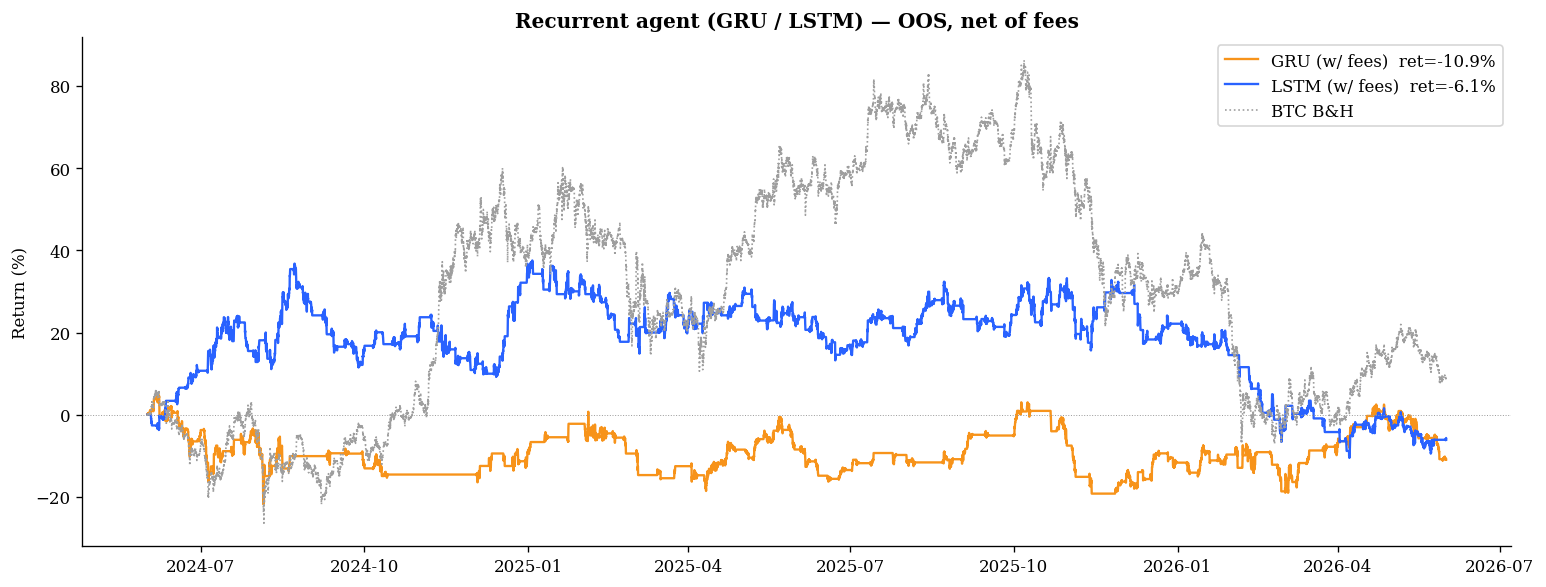

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({"font.family":"serif","axes.spines.top":False,"axes.spines.right":False,
                     "figure.dpi":120})
ACCENT="#F7931A"; BLUE="#2962FF"; GREY="#9E9E9E"

df = pd.read_parquet(R.UNIFIED); df.index = df.index.tz_localize(None) if df.index.tz else df.index
oos = df[df.index >= R.OOS_START]
bh = (oos["close"].values/oos["close"].values[0] - 1)*100

fig, ax = plt.subplots(figsize=(13,5))
for cell, col in [("GRU", ACCENT), ("LSTM", BLUE)]:
    arts = REPO/"artifacts"/"notebooks_v2"/("09_gru" if cell=="GRU" else "09_lstm")
    eqf = arts/"oos_equity_wfees.npy"
    if eqf.exists():
        eq = np.load(eqf)
        ax.plot(oos.index[:len(eq)], (eq-1)*100, lw=1.4, color=col,
                label=f"{cell} (w/ fees)  ret={results[cell]['backtest_wfees']['total_ret']:+.1%}")
ax.plot(oos.index, bh, color=GREY, lw=1.0, ls=":", label="BTC B&H")
ax.axhline(0, color=GREY, lw=0.6, ls=":"); ax.set_ylabel("Return (%)")
ax.set_title("Recurrent agent (GRU / LSTM) — OOS, net of fees", fontweight="bold"); ax.legend()
fig.tight_layout(); plt.show()


## 4 · Classical baseline — ARIMA(1,1,1) vs the random-walk null

The advisor's sharp version of the question: *if an unpromising classical model returns nearly the
same as the AI, the AI isn't justified.* The forecasting-accuracy table answers it directly — ARIMA
is compared against the naive random-walk forecast (next-bar return = 0) on a walk-forward 1-step
basis. The trading equity is the standard ARIMA long/short rule, net of the same taker fee.

In [4]:
from hmats.mas import arima_benchmark as ab
cache = REPO/"data"/"external"/"arima_oos.parquet"
if cache.exists():
    fc = pd.read_parquet(cache)
else:
    fc = ab.compute(df["close"])
acc = ab.forecast_accuracy(fc)
eq = fc["eq_arima"].values
print("=== ARIMA(1,1,1) trading baseline (OOS, w/ fees) ===")
print(f"  return={eq[-1]-1:+.1%}  sharpe={ab._sharpe(eq):.3f}  maxdd={ab._maxdd(eq):.1%}  bars={len(fc)}")
print("\n=== Forecast accuracy: ARIMA vs random-walk null ===")
for k,v in acc.items():
    print(f"  {k:34s} {v}")
print("\nReading: directional accuracy near 50% and ~0% RMSE improvement over the random walk means "
      "there is no exploitable *linear* structure — which is exactly what motivates the nonlinear agents.")


=== ARIMA(1,1,1) trading baseline (OOS, w/ fees) ===
  return=-15.3%  sharpe=-0.182  maxdd=-44.3%  bars=17520

=== Forecast accuracy: ARIMA vs random-walk null ===
  rmse_arima                         0.004981289719709214
  rmse_random_walk                   0.004978440376506404
  rmse_improvement_pct               -0.0572
  directional_accuracy_arima         0.5138

Reading: directional accuracy near 50% and ~0% RMSE improvement over the random walk means there is no exploitable *linear* structure — which is exactly what motivates the nonlinear agents.


## 5 · Full fund leaderboard (run after promotion/exclusion is wired into mas07)

In [5]:
from hmats.mas import mas07
out = mas07.run_pipeline(save=True, verbose=True)


=== Candidate validation-window Sharpe (2023-06->2024-05, informative only) ===
  lgbm                 val Sharpe  1.7913 -> IN FUND
  mamba                val Sharpe  1.7453 -> IN FUND
  tcn                  val Sharpe  1.8662 -> IN FUND
  patch                val Sharpe -1.0905 -> excluded
  trend                val Sharpe  0.1574 -> IN FUND
  volbreak             val Sharpe -0.4555 -> excluded
  sentiment_regime     val Sharpe  -0.114 -> excluded
  dominance_rotation   val Sharpe  0.7859 -> IN FUND
=== Per-regime competence priors (pre-OOS Sharpe, normalised, leak-free) ===
                     chop   bull   bear
lgbm                0.184  0.388  0.000
mamba               0.461  0.367  0.000
tcn                 0.292  0.149  0.119
trend               0.063  0.000  0.603
dominance_rotation  0.000  0.097  0.278

Predeclared final roster: ['lgbm', 'mamba', 'tcn', 'trend', 'dominance_rotation']
Excluded candidates: ['patch', 'volbreak', 'sentiment_regime', 'crossasset', 'rnn_gru', 'rnn_